# Why People Made Changes — Free-Text Analysis (trig.csv)
TRIG_1Text and TRIG_2Text are open-ended answers explaining the reason for renovation.
Responses are keyword-matched into thematic categories. ~62 % could be classified;
the rest are too specific or ambiguous and appear as *Sonstige*.

Text responses to classify: 1783
Total: 1783  |  classified: 1102 (62%)


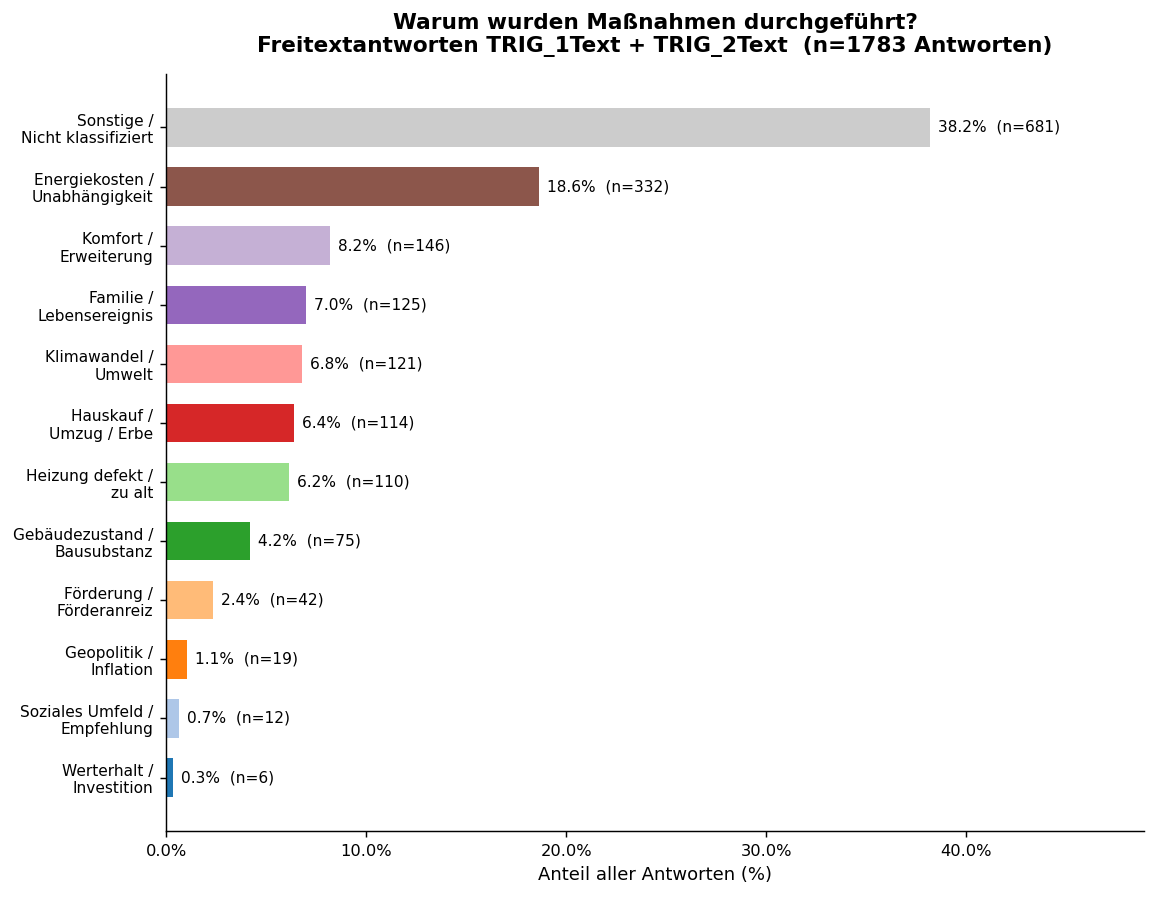

In [1]:
import csv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from collections import Counter

# ── Load ──────────────────────────────────────────────────────────────────────
with open("../data/processed/trig.csv") as f:
    rows = list(csv.DictReader(f))

SKIP = {"", "nein", "ja", "keine", "nan", "-", "k.a.", "keine angabe"}
all_texts = [
    r[col].strip().lower()
    for r in rows
    for col in ["TRIG_1Text", "TRIG_2Text"]
    if r[col].strip().lower() not in SKIP
]
print(f"Text responses to classify: {len(all_texts)}")

# ── Keyword categories (first match wins) ─────────────────────────────────────
categories = [
    ("Energiekosten /\nUnabhängigkeit", [
        "energieverbrauch","energiekosten","energiekrise","energiepreis","ölpreis",
        "stromkosten","stromverbrauch","gaskosten","gaspreise","heizkosten",
        "energie spar","kosten spar","kosteneinspar","geld spar","ersparnis",
        "sparen","sparsam","unabhängigkeit","unabhängig","abhängigkeit",
        "raus aus dem öl","energiekonzerne","energieversorg","hohe kosten",
        "günstiger","billiger","amortis","refinanzier","rentabilität",
        "hoher heizbedarf","energieausweis","energieverbr","energieeffizienz",
        "heizungskosten","laufende kosten","laufenden kosten","langfristig kosten",
        "geld","erdölkrise","blackout","energiekriese","sicher",
    ]),
    ("Klimawandel /\nUmwelt", [
        "klimawandel","energiewende","umwelt","co2","nachhaltigkeit","ökologisch",
        "klimaschutz","emissionen","fossile","klimakrise","grüner","erneuerbar",
        "dekarbonisier","treibhausgas","ökolog","grüne energie",
        "persönliche haltung zu energie",
    ]),
    ("Heizung defekt /\nzu alt", [
        "heizungstausch","heizkessel","ölbrenner","brenner","heizungsanlage",
        "heizkörper","kaputte heizung","defekte heizung","heizung alt",
        "heizung war alt","lebensende","ölkessel","gasheizung","heizung kaputt",
        "heizung defekt","heizungsausfall","feststoffheizung","gaskessel",
        "in die jahre gekommene heizung","heizung am ende","ölheizung",
        "altes heizsystem","alte heizung","funktionsfähigkeit der alten heizung",
    ]),
    ("Gebäudezustand /\nBausubstanz", [
        "renovierungsbedürftig","bausubstanz","altbestand","sanierungsbedarf",
        "veraltet","baufällig","undicht","uralt","marode","schimmel",
        "kellerfeuchte","feuchter keller","alte fassade","gebäudestandard",
        "zustand des gebäudes","substanz","baujahr","jahrzehnte",
        "50 jahre","60 jahre","70 jahre","80 jahre","von grund",
        "instandhaltung","instandsetzung","alterbedingt","altersbeding",
        "altbau","zeitgemäße sanierung","wasser im haus","feuchte",
    ]),
    ("Hauskauf /\nUmzug / Erbe", [
        "hauskauf","umzug","immobilie","einzug","erwerb","eigentum","eigenheim",
        "haus geerbt","übernahme","todesfall","erbschaft","erbe","geerbt",
        "verlegung des lebensmittel","neuer wohnort","zuzug","zugezogen",
        "wohnungskauf","haus überschrieben","überschrieben","kauf einer","kauf des",
        "erstbezug","neu gegründ",
    ]),
    ("Familie /\nLebensereignis", [
        "familie","familiengründung","kind","kinder","geburt","baby","nachwuchs",
        "auszug","pension","rente","altersheim","scheidung","trennung",
        "vergrößert","wachsende familie","kinder ausgezogen","im alter",
        "wann wir immer älter","lebensabschnitt","lebensphase","lebensumstand",
        "pandemie","neugestaltung",
    ]),
    ("Komfort /\nErweiterung", [
        "wohnklima","komfort","kälte","kalt","warm","wärme","zugluft",
        "schöneres wohnen","behaglichkeit","wohnqualität","bequem",
        "automatisch","moderner","modernisier","angenehmer","lebensqualität",
        "zimmerausbau","platzmangel","erweiterung","zubau","ausbau",
        "bessere nutzung","mehr platz","wohnfläche","umbau","anbau",
        "optik","stand der technik","platzgewinn","wohnraumbedarf",
        "barrierefreiheit","barrierefrei",
    ]),
    ("Soziales Umfeld /\nEmpfehlung", [
        "gespräch mit freund","empfehlung","freund","nachbar","bekannte",
        "verwandte","beraten","beratung","handwerker","architekt","fachmann",
    ]),
    ("Förderung /\nFörderanreiz", [
        "förderung","förderanreiz","förderangebot","subvention","zuschuss",
        "förderprogramm","geförder","energieberatung",
    ]),
    ("Geopolitik /\nInflation", [
        "ukraine","krieg","inflation","preissteigerung","teuerung","russland",
    ]),
    ("Werterhalt /\nInvestition", [
        "werterhalt","wertsteigerung","investition","erhalten des gebäudes",
        "werterhaltung","immobilienwert","wert des hauses",
    ]),
]

matched_cats = Counter()
n_unmatched  = 0
for text in all_texts:
    found = False
    for cat, keywords in categories:
        if any(kw in text for kw in keywords):
            matched_cats[cat] += 1
            found = True
            break
    if not found:
        n_unmatched += 1

matched_cats["Sonstige /\nNicht klassifiziert"] = n_unmatched

total = sum(matched_cats.values())
print(f"Total: {total}  |  classified: {total-n_unmatched} ({(total-n_unmatched)/total*100:.0f}%)")

# ── Sort: classified by count desc, Sonstige always last ─────────────────────
SONSTIGE_KEY = "Sonstige /\nNicht klassifiziert"
sorted_items = sorted(
    [(k, v) for k, v in matched_cats.items() if k != SONSTIGE_KEY],
    key=lambda x: x[1]
) + [(SONSTIGE_KEY, matched_cats[SONSTIGE_KEY])]

labels = [k for k, _ in sorted_items]
values = [v for _, v in sorted_items]
pcts   = [v / total * 100 for v in values]

# Colours: each category gets its own colour; Sonstige = grey
palette = plt.cm.tab20.colors
colors  = [palette[i % 20] for i in range(len(labels) - 1)] + ["#cccccc"]

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

fig, ax = plt.subplots(figsize=(9, 7))
y    = np.arange(len(labels))
bars = ax.barh(y, pcts, color=colors, height=0.65)

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=8.5)
ax.set_xlabel("Anteil aller Antworten (%)")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(0, max(pcts) * 1.28)


for bar, pct, cnt in zip(bars, pcts, values):
    ax.text(
        bar.get_width() + 0.4,
        bar.get_y() + bar.get_height() / 2,
        f"{pct:.1f}%  (n={cnt})",
        va="center", fontsize=8.5
    )

ax.set_title(
    f"Warum wurden Maßnahmen durchgeführt?\n"
    f"Freitextantworten TRIG_1Text + TRIG_2Text  (n={total} Antworten)",
    pad=12
)

plt.tight_layout()
plt.show()